In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.interpolate
import importlib

In [2]:
import modules.loaddata
spectral_q, spectral_vals = modules.loaddata.load_spectral("./data/sf_nu_responses/")
ab_initio_q, ab_initio_vals = modules.loaddata.load_ab_initio("./data/ab_initio_nu_responses/")

In [3]:
print(spectral_q)
print(ab_initio_q)

[ 50.  75. 100. 125. 150. 175. 200. 225. 250. 275. 300. 325. 350. 375.
 400. 425.]
[ 50 100 150 200 250 300 350 400]


# Data prep

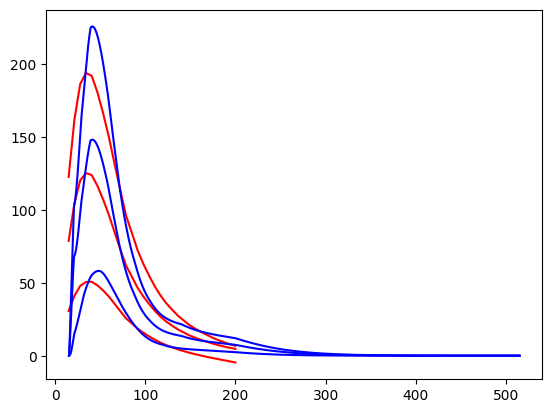

In [ ]:
for curve in spectral_vals[6]:
    plt.plot(curve[0], curve[1], color="red")
for curve in ab_initio_vals[3]:
    plt.plot(curve[0], curve[1], color="blue")
plt.show()

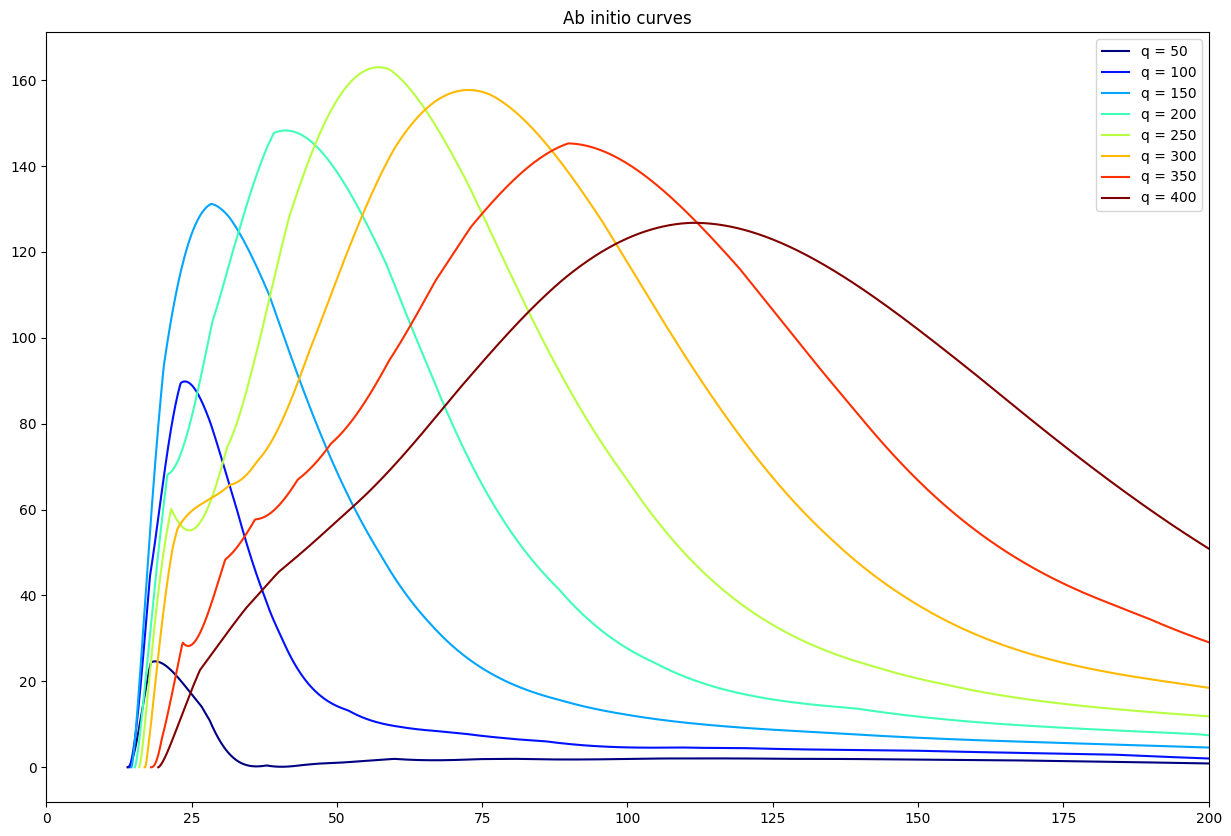

In [27]:
from modules.utils import generate_colourscale
colors = generate_colourscale(len(ab_initio_q))
plt.figure(figsize=(15, 10))
curve_idx = 0
for i, (q, vals) in enumerate(zip(ab_initio_q, ab_initio_vals)):
    plt.plot(vals[curve_idx][0], vals[curve_idx][1], label=f'q = {q}', color=colors[i])
plt.xlim(0, 200)
plt.legend()
plt.title("Ab initio curves")
plt.show()

In [5]:
import modules.interpolation_preprocess
import importlib
importlib.reload(modules.interpolation_preprocess)
preprocess_transform_params = modules.interpolation_preprocess.get_transform_params(spectral_q, spectral_vals)
spectral_vals_transformed = modules.interpolation_preprocess.transform_data(spectral_q, spectral_vals, preprocess_transform_params)

/mnt/bogdisk/_/plugg/kandidat/neutrino_bsc_26/modules/utils.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(gaussian, x, y, p0=initial_guess, maxfev=10000)


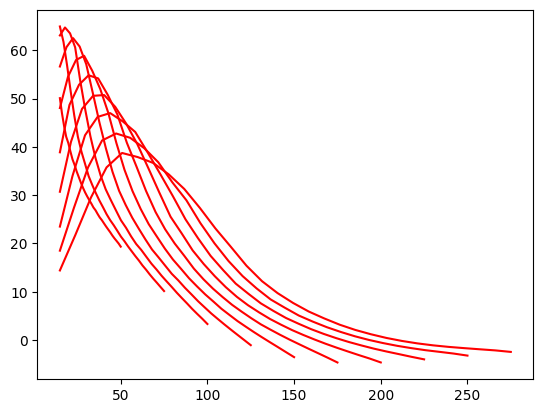

In [10]:
for i in range(10):
    plt.plot(spectral_vals[i][1][0], spectral_vals[i][1][1], color="red")

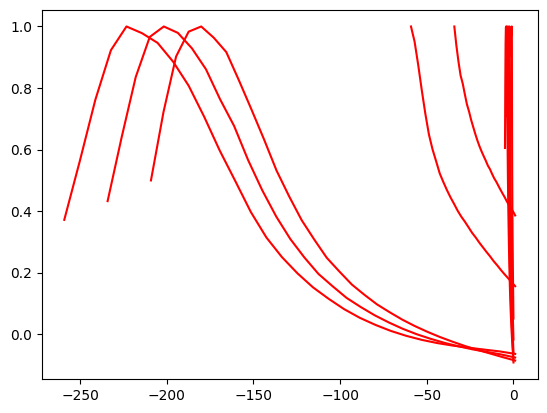

In [11]:
for i in range(10):
    plt.plot(spectral_vals_transformed[i][1][0], spectral_vals_transformed[i][1][1], color="red")

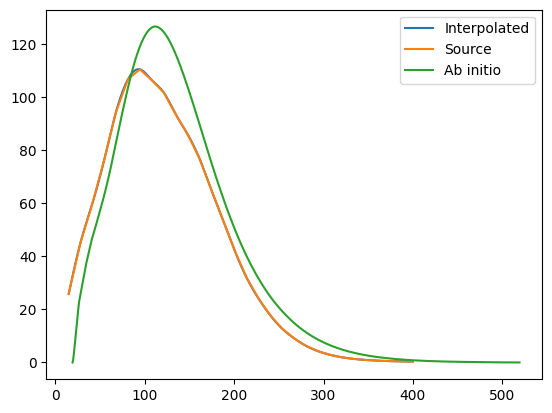

In [6]:
from scipy.interpolate import RegularGridInterpolator

def build_spectral_interpolator(q_vals, vals, curve_index):
    wvals = vals[:, curve_index, 0, :]
    yvals = vals[:, curve_index, 1, :]

    points = []
    vals = []
    for i in range(len(q_vals)):
        for j in range(wvals.shape[1]):
            points.append((q_vals[i], wvals[i, j]))
            vals.append(yvals[i, j])

    interpolator_function = scipy.interpolate.CloughTocher2DInterpolator(
        points,
        values=vals,
        # fill_value=0.0, # Need to trim training data to not fall outside this 
        # method="cubic",
        # bounds_error=True,
        # fill_value=np.nan,
    )
    return interpolator_function

spectral_functions = []
for i in range(spectral_vals.shape[1]):
    f = build_spectral_interpolator(spectral_q, spectral_vals, i)
    spectral_functions.append(f)

# Test for q = 400MeV
wcoord = np.arange(0, 500, 1)
vals = spectral_functions[0]((400, np.array(wcoord)))
curve_idx = 0
plt.plot(wcoord, vals, label="Interpolated")
plt.plot(spectral_vals[-2,curve_idx,0], spectral_vals[-2,curve_idx,1], label="Source")
plt.plot(ab_initio_vals[-1,curve_idx,0], ab_initio_vals[-1,curve_idx,1], label="Ab initio")
plt.legend()

In [7]:
# Compute residuals
residual = ab_initio_vals.copy()
for (q_idx, q) in enumerate(ab_initio_q):
    for (curve_idx, curve) in enumerate(ab_initio_vals[q_idx]):
        residual[q_idx, curve_idx, 1] = curve[1] - spectral_functions[curve_idx]((q, curve[0]))

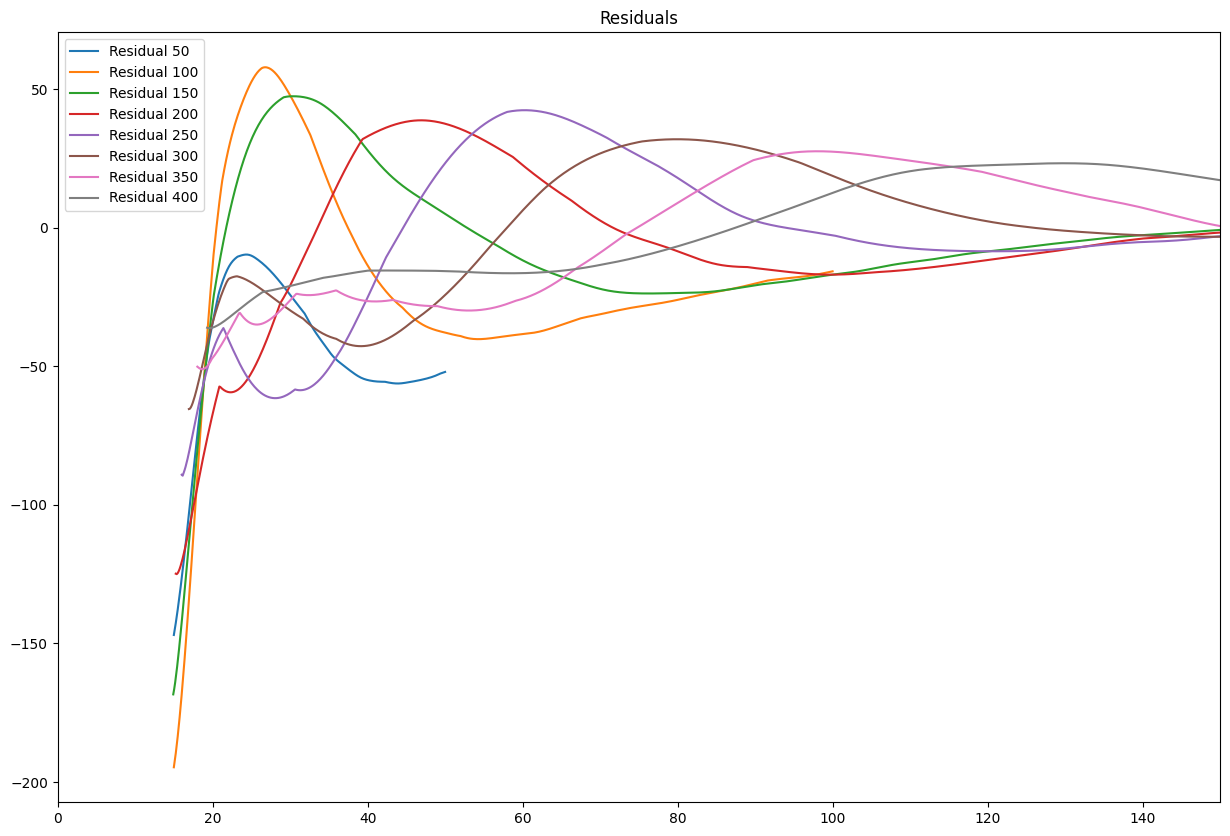

In [9]:
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.plot(residual[i,curve_idx,0], residual[i,curve_idx,1], label=f"Residual {ab_initio_q[i]}")
plt.xlim(0, 150)
plt.title("Residuals")
plt.legend()

# Torch Setup

In [6]:
from torch import nn
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
if device == "cuda":
    print("CUDA available")
else:
    print("⚠️ CUDA not available ⚠️")

CUDA available


In [8]:
# Prep data
X_train = []
Y_train = []


for q_idx, q in enumerate(ab_initio_q):
    # TODO: Check that they actually share w values
    if q == 200: # leave out for testing
        continue
    w_vals = residual[q_idx, 0, 0]
    
    y0 = residual[q_idx, 0, 1]
    y1 = residual[q_idx, 1, 1]
    y2 = residual[q_idx, 2, 1]
    
    for i, w in enumerate(w_vals):
        # Skip points where any of the curves resulted in NaN. The spectral functions cover a significantly smaller region than the ab initio curves
        if not (np.isnan(y0[i]) or np.isnan(y1[i]) or np.isnan(y2[i])):
            X_train.append([w, q]) # in: [w, q]
            Y_train.append([y0[i], y1[i], y2[i]]) # out: residual for each curve

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)

# Normalized data
X_mean = X_train.mean(dim=0, keepdim=True)
X_std = X_train.std(dim=0, keepdim=True)
Y_mean = Y_train.mean(dim=0, keepdim=True)
Y_std = Y_train.std(dim=0, keepdim=True)

X_train = (X_train - X_mean) / X_std
Y_train = (Y_train - Y_mean) / Y_std

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
train_dataloader = DataLoader(train_dataset, batch_size=20000, shuffle=True)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

X_train shape: torch.Size([11882, 2])
Y_train shape: torch.Size([11882, 3])


In [10]:
# Create model
class ResidualNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(2, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 3),
        )
        self.loss_fn = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)

    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
    def run_training(self, dataloader):
        size = len(dataloader.dataset)
        self.train()
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = self(X)
            loss = self.loss_fn(pred, y)
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()
            if batch % 100 == 0:
                loss, current = loss.item(), (batch + 1) * len(X)
                print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    def run_test(self, dataloader):
        size = len(dataloader.dataset)
        num_batches = len(dataloader)
        self.eval()
        test_loss, correct = 0, 0
        with torch.no_grad():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
                pred = self(X)
                test_loss += self.loss_fn(pred, y).item()
                correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        test_loss /= num_batches
        correct /= size
        print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    def make_transformed_prediction(self, q, wvals):
        inputs = torch.tensor([[w, q] for w in wvals], dtype=torch.float32).to(device)
        inputs = (inputs - X_mean) / X_std
        with torch.no_grad():
            preds = model(inputs)
            preds = (preds * Y_std + Y_mean).cpu().numpy()
        return preds

model = ResidualNN().to(device)
print(model)

ResidualNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=3, bias=True)
  )
  (loss_fn): MSELoss()
)


In [11]:
for i in range(1000):
    print(f"Epoch {i+1}\n-------------------------------")
    model.run_training(train_dataloader)
    # model.run_test(train_dataloader)

Epoch 1
-------------------------------
loss: 0.999154  [11882/11882]
Epoch 2
-------------------------------
loss: 0.985246  [11882/11882]
Epoch 3
-------------------------------
loss: 0.973357  [11882/11882]
Epoch 4
-------------------------------
loss: 0.961284  [11882/11882]
Epoch 5
-------------------------------
loss: 0.948744  [11882/11882]
Epoch 6
-------------------------------
loss: 0.935355  [11882/11882]
Epoch 7
-------------------------------
loss: 0.920446  [11882/11882]
Epoch 8
-------------------------------
loss: 0.904162  [11882/11882]
Epoch 9
-------------------------------
loss: 0.887027  [11882/11882]
Epoch 10
-------------------------------
loss: 0.869837  [11882/11882]
Epoch 11
-------------------------------
loss: 0.853042  [11882/11882]
Epoch 12
-------------------------------
loss: 0.837179  [11882/11882]
Epoch 13
-------------------------------
loss: 0.822511  [11882/11882]
Epoch 14
-------------------------------
loss: 0.808155  [11882/11882]
Epoch 15
------

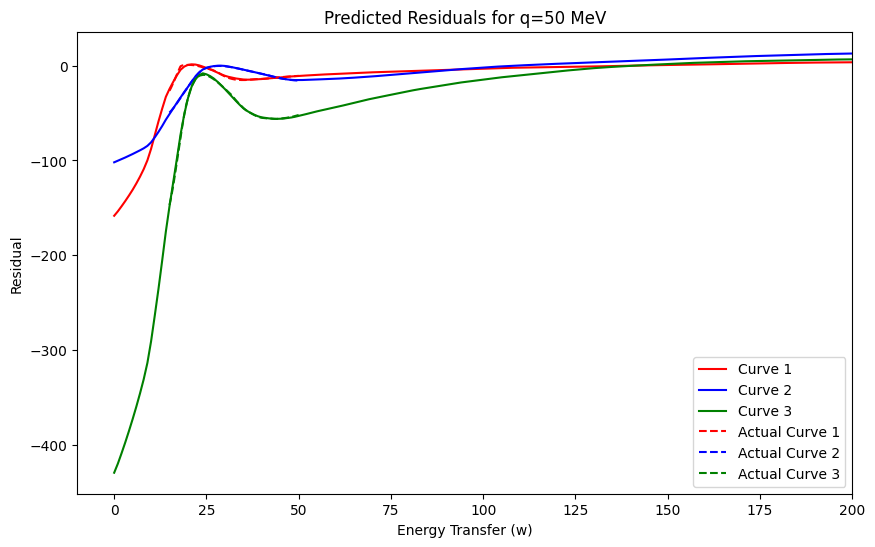

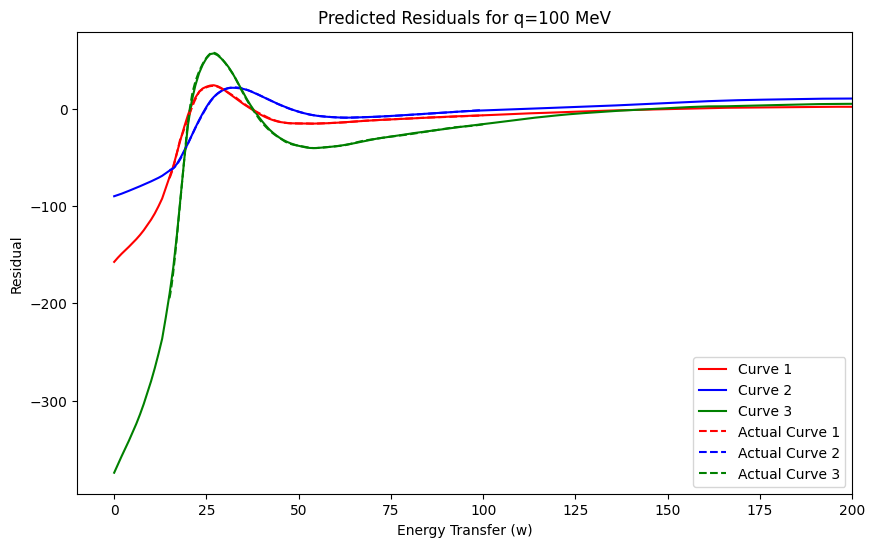

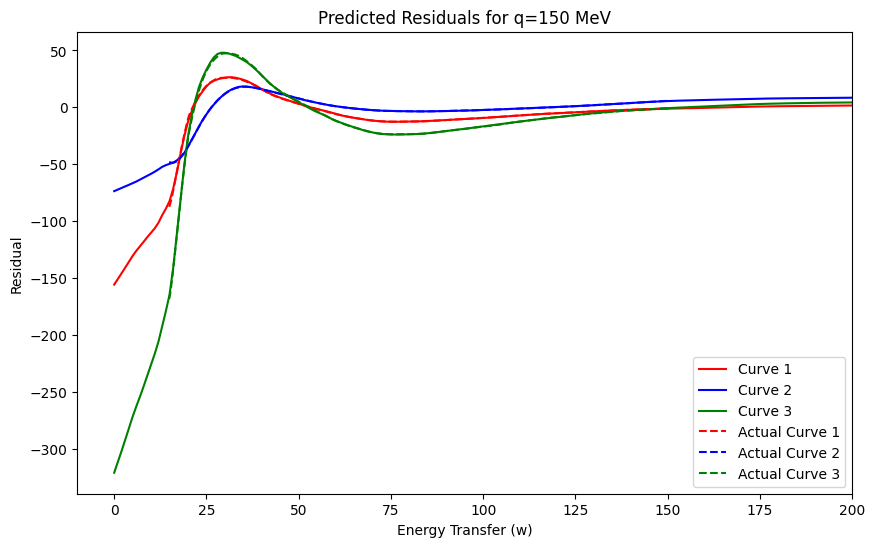

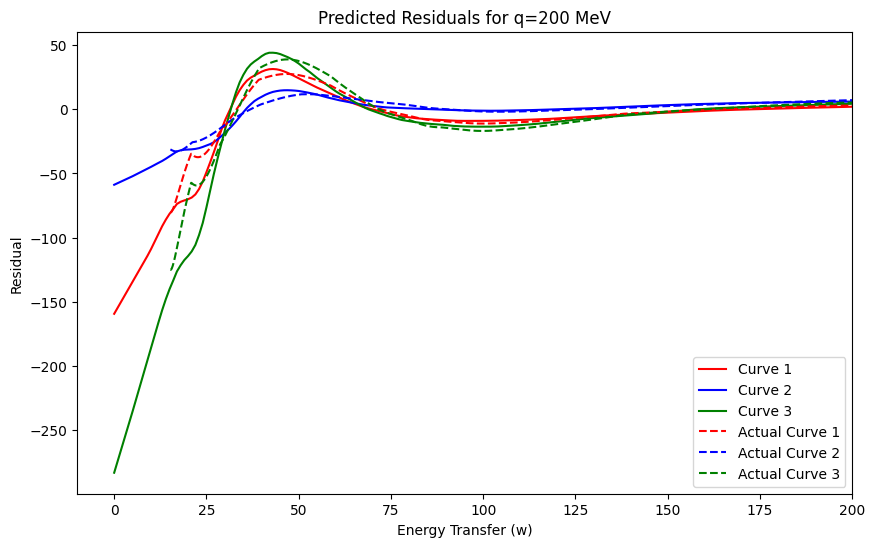

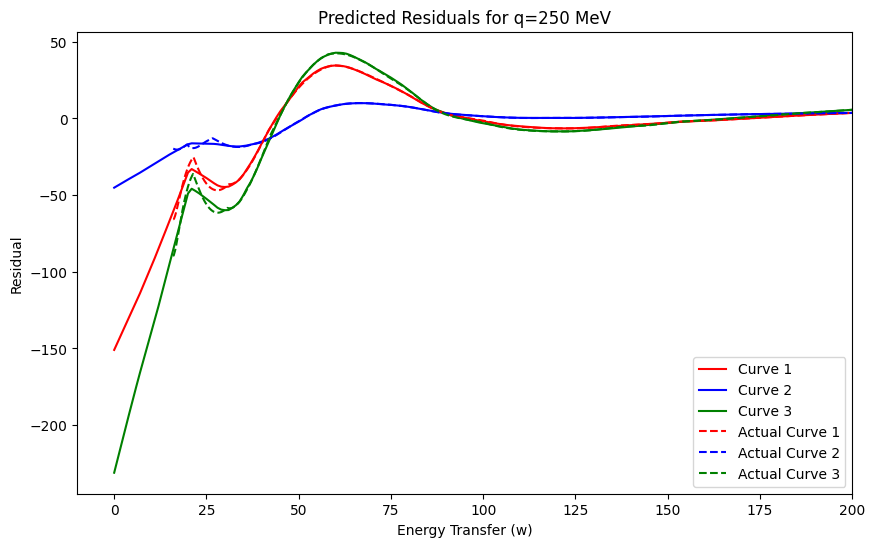

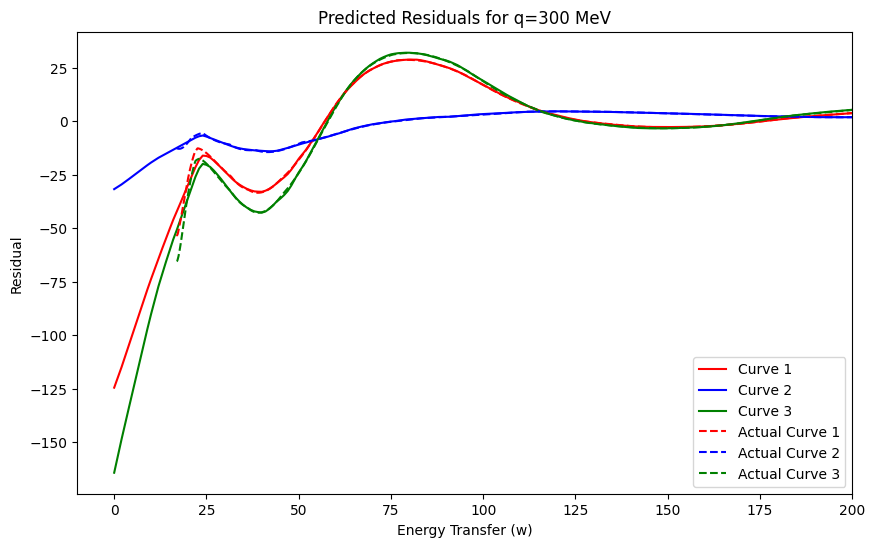

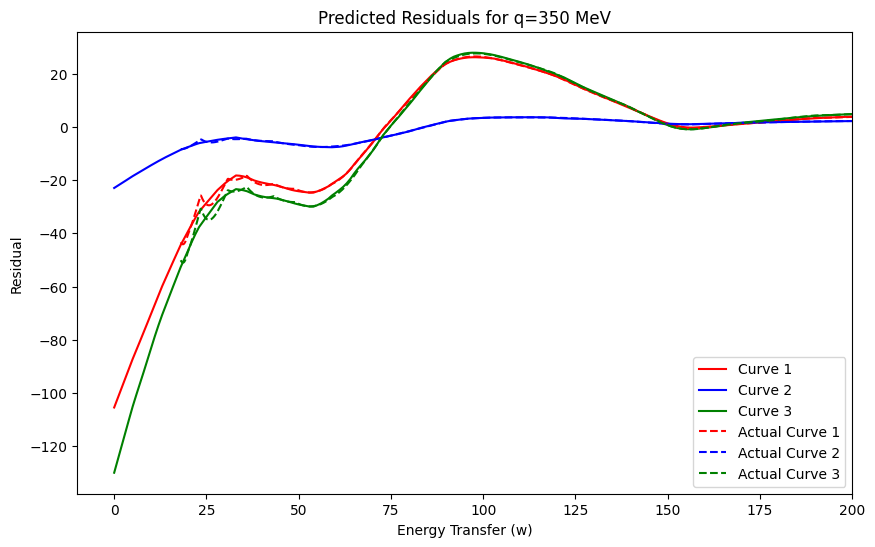

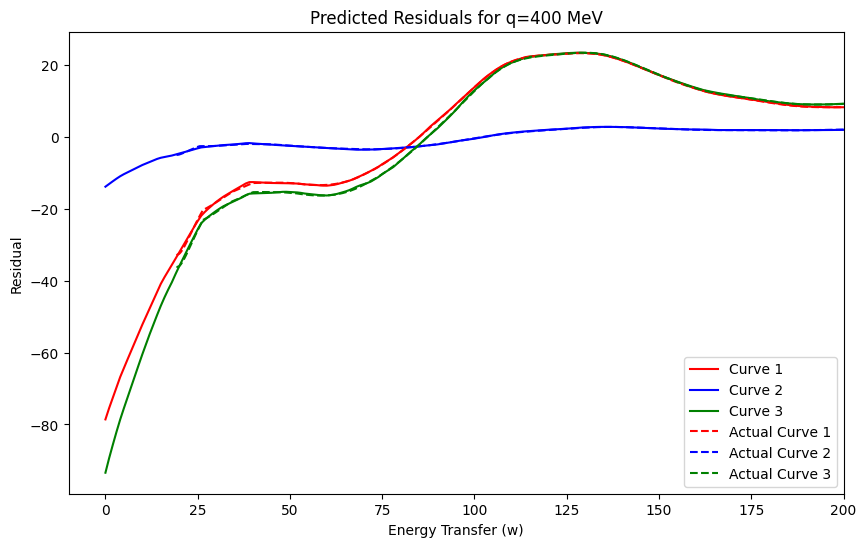

In [12]:
wvals = np.arange(0, 500, 1)
for idx, q in enumerate(ab_initio_q):
    inputs = torch.tensor([[w, q] for w in wvals], dtype=torch.float32).to(device)
    inputs = (inputs - X_mean) / X_std
    with torch.no_grad():
        preds = model(inputs)
        preds = (preds * Y_std + Y_mean).cpu().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.plot(wvals, preds[:, 0], label="Curve 1", color="red")
    plt.plot(wvals, preds[:, 1], label="Curve 2", color="blue")
    plt.plot(wvals, preds[:, 2], label="Curve 3", color="green")

    # Actual residuals
    plt.plot(residual[idx, 0, 0], residual[idx, 0, 1], label="Actual Curve 1", linestyle="dashed", color="red")
    plt.plot(residual[idx, 1, 0], residual[idx, 1, 1], label="Actual Curve 2", linestyle="dashed", color="blue")
    plt.plot(residual[idx, 2, 0], residual[idx, 2, 1], label="Actual Curve 3", linestyle="dashed", color="green")

    plt.title(f"Predicted Residuals for q={q} MeV")
    plt.xlabel("Energy Transfer (w)")
    plt.ylabel("Residual")
    plt.legend()
    plt.xlim(-10, 200)
    # plt.ylim(-200, 200)
    plt.show()

In [48]:
ab_initio_q

array([ 50, 100, 150, 200, 250, 300, 350, 400])

Text(0, 0.5, 'Response')

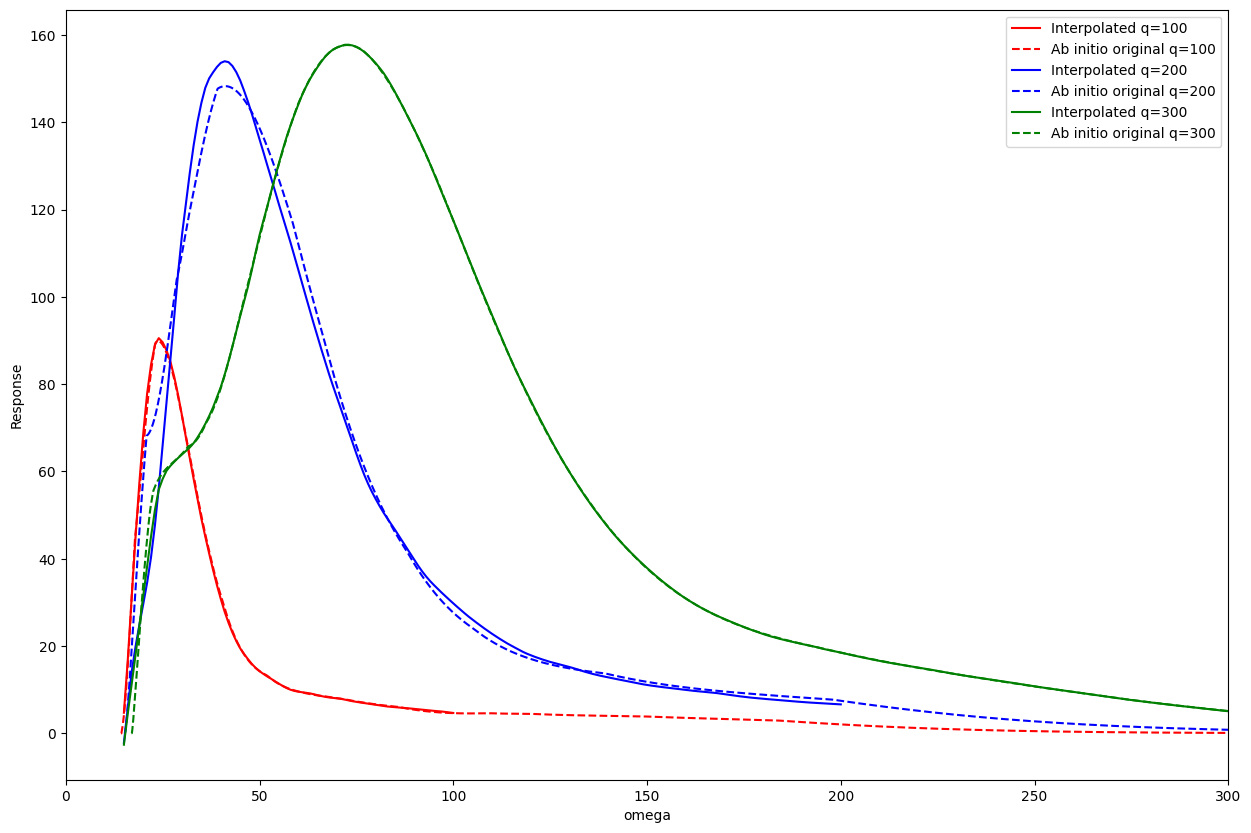

In [13]:
plt.figure(figsize=(15, 10))
colors = ["red", "blue", "green"]
for i, (ab_initio_index, q) in enumerate(zip([1, 3, 5], [100, 200, 300])):
    wvals = np.arange(0, 500, 1)
    residual_pred = model.make_transformed_prediction(q, wvals)
    final_curve = spectral_functions[0]((q, wvals)) + residual_pred[:, 0]
    plt.plot(wvals, final_curve, label=f"Interpolated q={q}", color=colors[i])
    plt.plot(ab_initio_vals[ab_initio_index,0,0], ab_initio_vals[ab_initio_index,0,1], label=f"Ab initio original q={q}", linestyle="--", color=colors[i])

plt.legend()
plt.xlim(0, 300)
plt.xlabel("omega")
plt.ylabel("Response")